# Session 6 — Dimensionality Reduction & Visualization
### PCA • t‑SNE • UMAP • Parallel Coordinates • RBFN

**Datasets:**
- **Digits (sklearn)** → PCA, t‑SNE, UMAP, RBFN
- **Wine (sklearn)** → Parallel Coordinates

## 1) Environment Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

import plotly.express as px

pd.set_option("display.max_columns", 120)


## 2) Load Datasets (Digits & Wine)

In [ ]:
# Digits (for PCA, t-SNE, UMAP, RBFN)
digits = load_digits()
X_digits = digits.data   # (1797, 64)
y_digits = digits.target # 10 classes (0-9)

print("Digits:", X_digits.shape, "labels:", np.unique(y_digits))

# Wine (for Parallel Coordinates)
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="label")

print("Wine:", X_wine.shape, "labels:", np.unique(y_wine))
X_wine.head()


Digits: (1797, 64) labels: [0 1 2 3 4 5 6 7 8 9]
Wine: (178, 13) labels: [0 1 2]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3) Parallel Coordinates — Wine Dataset

**Question**

Using the wine dataset, represent the parallel coordinate plot.

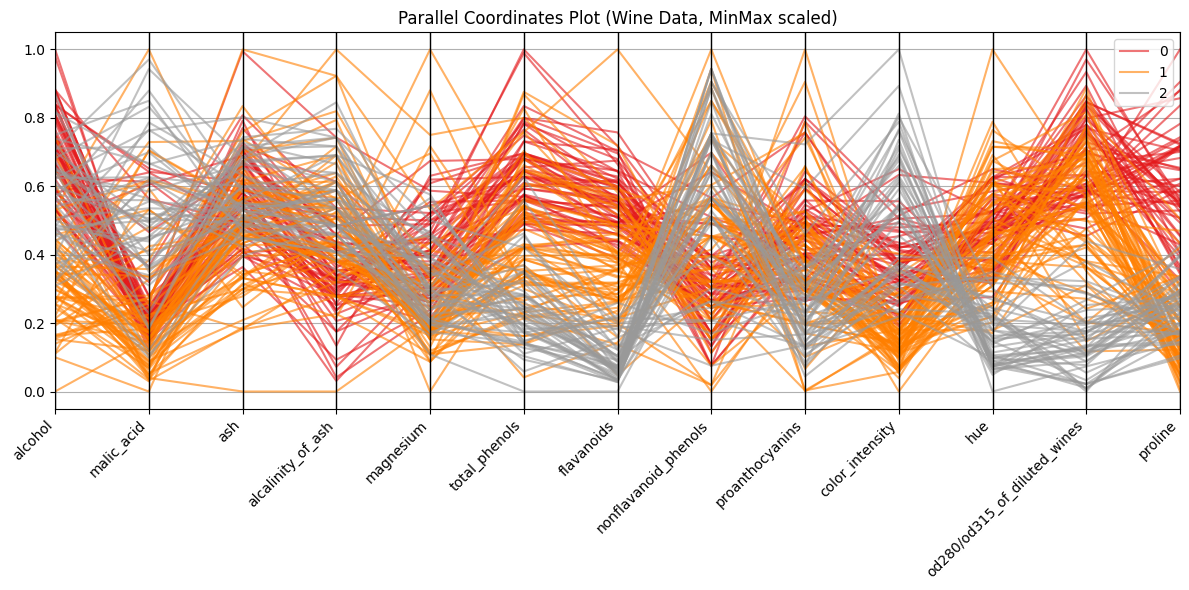

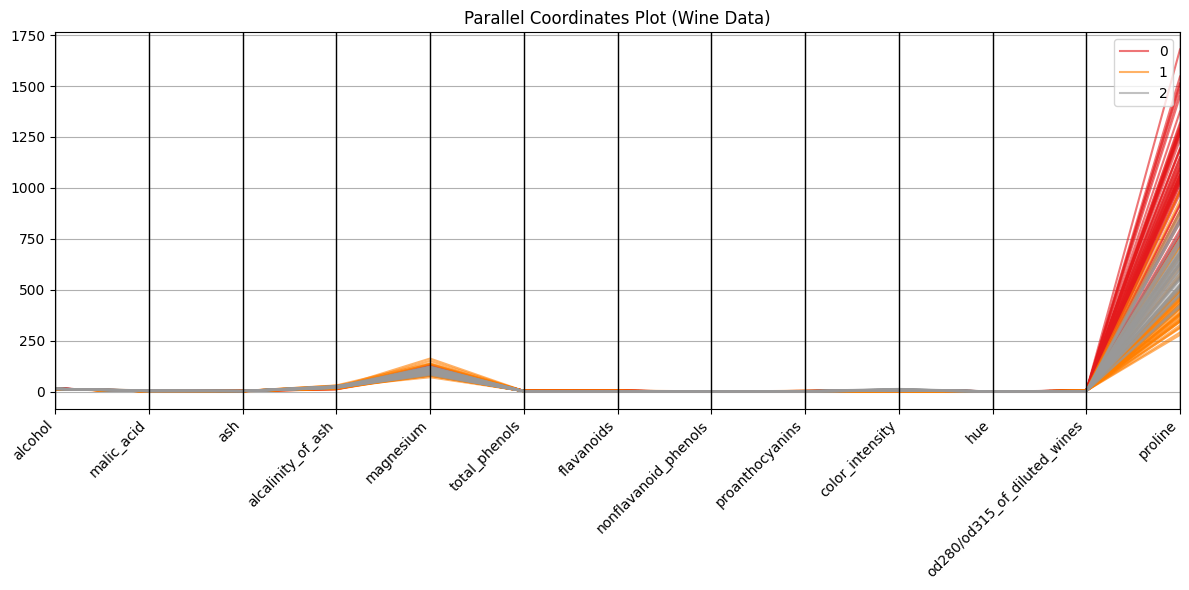

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import parallel_coordinates

scaler = MinMaxScaler()
wine_norm = scaler.fit_transform(X_wine)

wine_norm_df = pd.DataFrame(wine_norm, columns=wine.feature_names)
wine_norm_df["label"] = y_wine.to_numpy()  # ensure alignment

wine_df = pd.DataFrame(X_wine, columns=wine.feature_names)
wine_df["label"] = y_wine.to_numpy()  # ensure alignment

# Plot
plt.figure(figsize=(12,6))
parallel_coordinates(wine_norm_df, "label", colormap=plt.cm.Set1, alpha=0.6)
plt.title("Parallel Coordinates Plot (Wine Data, MinMax scaled)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Plot
plt.figure(figsize=(12,6))
parallel_coordinates(wine_df, "label", colormap=plt.cm.Set1, alpha=0.6)
plt.title("Parallel Coordinates Plot (Wine Data)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Questions — Parallel Coordinates (Wine)
**Q2.1** Which wine features appear most discriminative across the 3 classes?  
**Solution:** Typically 'flavanoids', 'od280/od315_of_diluted_wines', and 'proline' show strong separation.

**Q2.2** What limitation do you notice with many overlapping lines?  
**Solution:** Overplotting/clutter reduces interpretability; brushing/filtering helps.

## 4) Standardize — Digits

In [ ]:
scaler = StandardScaler()
X_digits_std = scaler.fit_transform(X_digits)
print("Digits standardized:", X_digits_std.shape)


Digits standardized: (1797, 64)


## 5) PCA (2D) — Digits

Explained variance ratio: [0.12033916 0.09561054]
Total variance explained: 0.21594970500832789


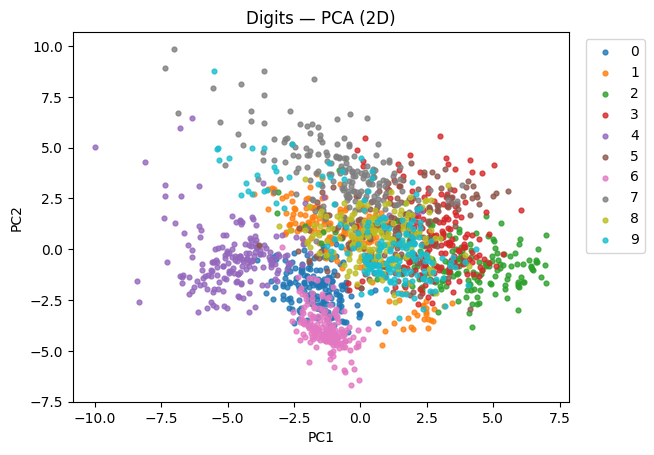

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_digits_std)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))


plt.figure()
labels = pd.Series(y_digits).astype(str)
for lab in labels.unique():
    idx = (labels == lab).values
    plt.scatter(X_pca[idx,0], X_pca[idx,1], s=12, alpha=0.8, label=lab)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Digits — PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Questions — PCA (Digits)
**Q3.1** What percentage of variance do PC1 and PC2 explain? Comments
**Solution:** 12% and 9%. it means most of the dataset's complexity lies in higher dimensions. But PCA is still useful for visualization, since clusters may still be separable even if the variance explained is relatively low.

**Q3.2** Do digit classes separate in PCA space?  
**Solution:** Partial separation; many classes overlap due to linear projection.

**Q3.3** How many PCs are needed to explain ~95% variance
**Solution:** 40.

## 6) t‑SNE (2D) — Digits

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


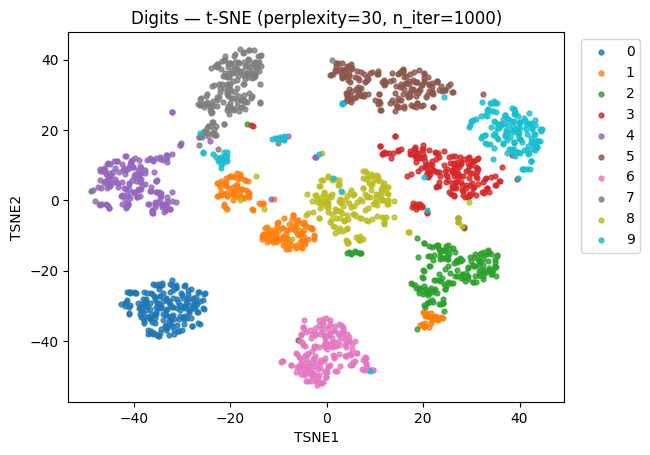

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


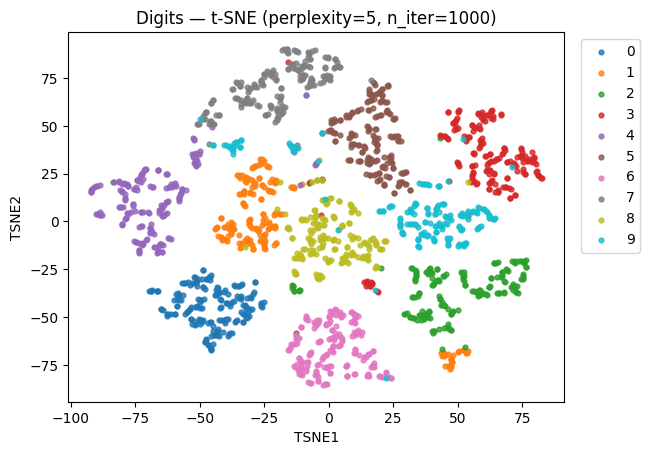

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


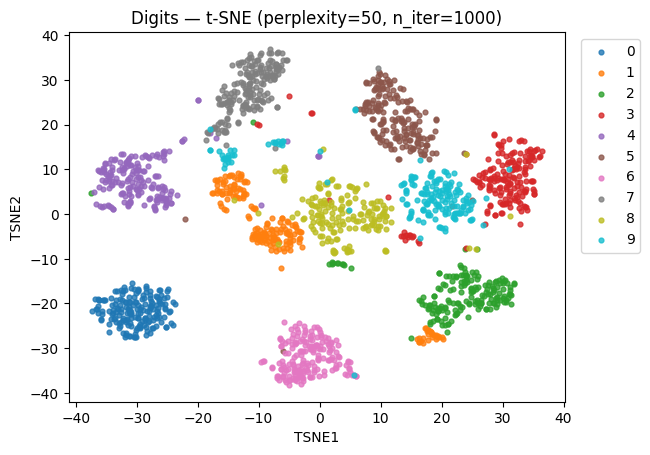

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


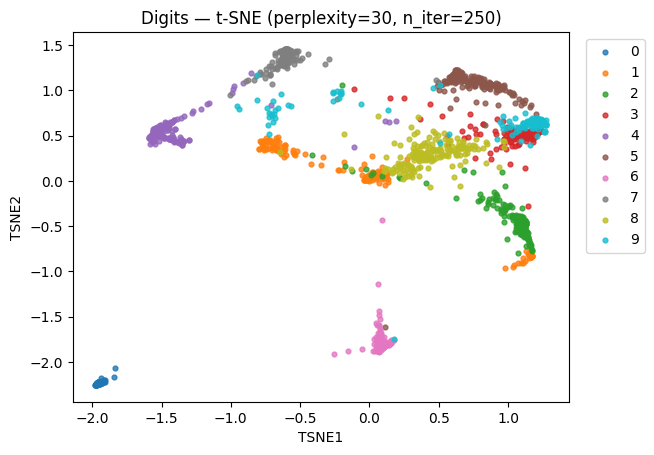

In [ ]:
def run_tsne_digits(perplexity=30, n_iter=1000, init='pca', random_state=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto",
                init=init, n_iter=n_iter, random_state=random_state)
    X_tsne = tsne.fit_transform(X_digits_std)
    plt.figure()
    labels = pd.Series(y_digits).astype(str)
    for lab in labels.unique():
        idx = (labels == lab).values
        plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=12, alpha=0.8, label=lab)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.title(f"Digits — t-SNE (perplexity={perplexity}, n_iter={n_iter})")
    plt.xlabel("TSNE1")
    plt.ylabel("TSNE2")
    plt.show()
    return X_tsne

X_tsne_default = run_tsne_digits(perplexity=30, n_iter=1000)
X_tsne_p5 = run_tsne_digits(perplexity=5, n_iter=1000)
X_tsne_p50 = run_tsne_digits(perplexity=50, n_iter=1000)
X_tsne_iter250 = run_tsne_digits(perplexity=30, n_iter=250)


### Questions — t‑SNE (Digits)
**Q4.1** With `perplexity=30`, do you see clear digit clusters?  
**Solution:** Yes, digits typically form well-separated local clusters.

**Q4.2** Compare `perplexity=5` vs `50`. What changes?  
**Solution:** p=5 → many tight, fragmented clusters; p=50 → smoother, sometimes merges nearby digits.

**Q4.3** Effect of `n_iter=250` vs `1000`?  
**Solution:** Fewer iterations yield noisier embeddings; more iterations stabilize clusters.

## 7) UMAP (2D) — Digits

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


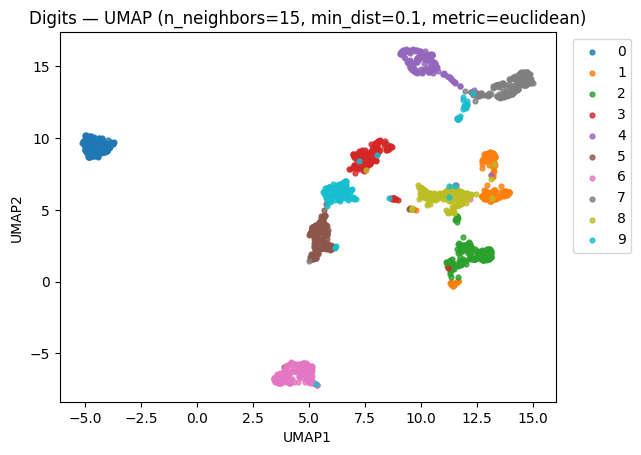

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


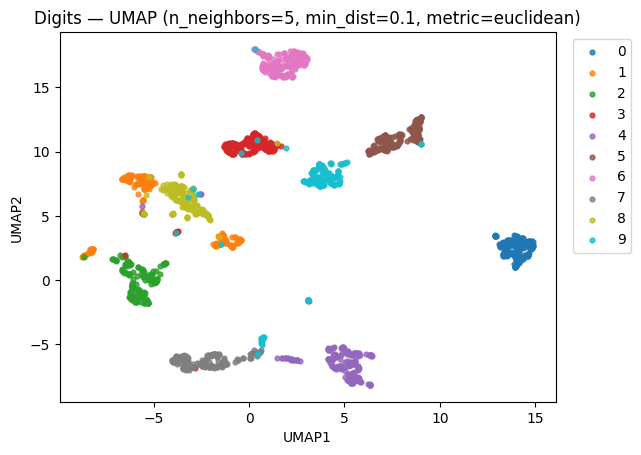

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


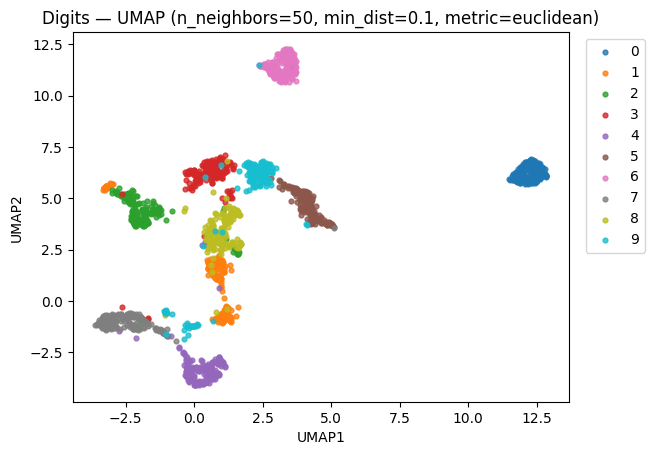

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


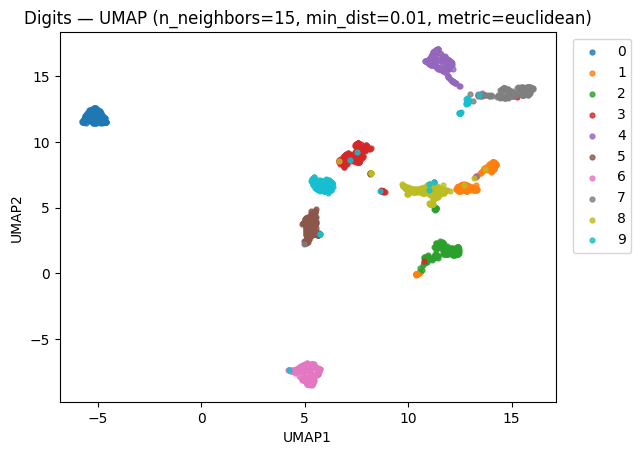

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


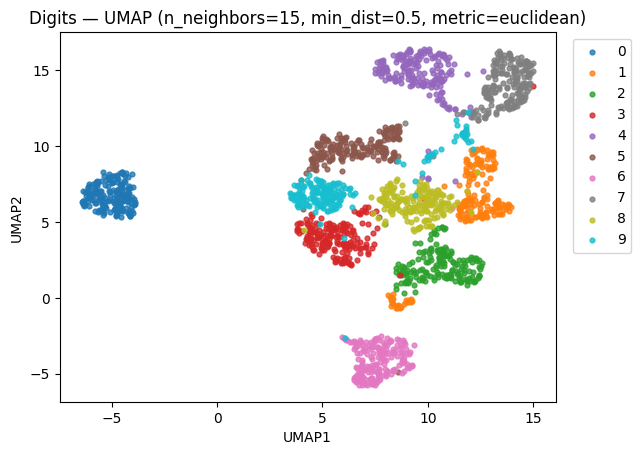

In [ ]:
def run_umap_digits(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42):

    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist,
                        metric=metric, random_state=random_state)
    X_umap = reducer.fit_transform(X_digits_std)
    plt.figure()
    labels = pd.Series(y_digits).astype(str)
    for lab in labels.unique():
        idx = (labels == lab).values
        plt.scatter(X_umap[idx,0], X_umap[idx,1], s=12, alpha=0.8, label=lab)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.title(f"Digits — UMAP (n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric})")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.show()
    return X_umap

X_umap_default = run_umap_digits(n_neighbors=15, min_dist=0.1)
X_umap_n5 = run_umap_digits(n_neighbors=5, min_dist=0.1)
X_umap_n50 = run_umap_digits(n_neighbors=50, min_dist=0.1)
X_umap_md001 = run_umap_digits(n_neighbors=15, min_dist=0.01)
X_umap_md05 = run_umap_digits(n_neighbors=15, min_dist=0.5)


### Questions — UMAP (Digits)
**Q5.1** Compare UMAP default to t‑SNE default. What differences do you see?  
**Solution:** UMAP is faster; preserves broader structure; clusters can be slightly less compact than t‑SNE depending on params.

**Q5.2** Change `n_neighbors` (5 vs 50). What happens?  
**Solution:** Smaller values emphasize local structure (more cluster fragmentation). Larger values smooth/merge clusters.

**Q5.3** Change `min_dist` (0.01 vs 0.5). How does cluster compactness change?  
**Solution:** Lower `min_dist` packs clusters tightly; higher spreads clusters with more overlap.

## 8) Compare PCA vs t‑SNE vs UMAP — CPU time

In [ ]:
import time

def time_tsne_digits():
    t0 = time.time()
    TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", n_iter=750, random_state=0).fit_transform(X_digits_std)
    return time.time() - t0

def time_umap_digits():
    if umap is None:
        return None
    t0 = time.time()
    umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=0).fit_transform(X_digits_std)
    return time.time() - t0

def time_pca_digits():
    t0 = time.time()
    PCA(n_components=2, random_state=0).fit_transform(X_digits_std)
    return time.time() - t0

tpca = time_pca_digits()
tusne = time_tsne_digits()
tumap = time_umap_digits()

print("Digits — Runtimes (sec):")
print("PCA :", tpca)
print("t-SNE:", tusne)
print("UMAP:", tumap if tumap is not None else "UMAP not installed")


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Digits — Runtimes (sec) — approx on this machine:
PCA : 0.00837254524230957
t-SNE: 11.277506113052368
UMAP: 7.124089956283569


### Questions — Comparison
**Q6.1** Which method shows the clearest digit separation?  
**Solution:** Typically t‑SNE or UMAP outperform PCA visually.

**Q6.2** Which is fastest/slowest on Digits?  
**Solution:** Usually PCA ≪ UMAP ≪ t‑SNE (verify with timing).

**Q6.3** Which preserves global structure better?  
**Solution:** UMAP tends to preserve more global topology; t‑SNE focuses on local neighborhoods.

# AFLW 2021 Season — Dimensionality Reduction
**Datasets:** Player statistics for the 2021 season of the Women’s Australian Football League.  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from google.colab import files

In [3]:
uploaded = files.upload()

Saving aflw.xlsx to aflw.xlsx


In [4]:
df = pd.read_excel("aflw.xlsx")
df.head()

,id,given_name,surname,number,team,position,time_pct,goals,behinds,kicks,handballs,disposals,marks,bounces,tackles,contested,uncontested,possessions,marks_in50,contested_marks,hitouts,one_pct,disposal,clangers,frees_for,frees_against,rebounds_in50,assists,accuracy,turnovers,intercepts,tackles_in50,shots,metres,clearances
0,CD_I1001678,Jordan,Zanchetta,2,Brisbane Lions,INT,63.00,0.0,0.0,5.00,2.50,7.50,1.50,0.0,3.00,3.50,3.5,7.00,1.00,1.0,0.0,0.0,60.25,2.0,1.00,1.00,0.00,0.0,0.0,1.5,2.0,0.50,0.50,72.5,0.50
1,CD_I1001679,Brianna,Green,3,West Coast Eagles,INT,61.25,0.0,0.0,2.50,3.75,6.25,0.25,0.0,2.25,2.25,4.5,6.75,0.00,0.0,0.0,1.5,67.15,0.5,0.50,0.50,0.50,0.0,0.0,1.0,2.0,0.00,0.00,58.5,0.25
2,CD_I1001681,Jodie,Hicks,5,GWS Giants,HFFR,76.50,0.0,0.5,3.75,3.00,6.75,1.00,0.0,2.25,3.50,3.0,6.50,0.25,0.0,0.0,0.5,37.20,2.5,0.25,1.25,0.25,0.0,0.0,2.5,0.5,0.75,0.75,76.0,1.25
3,CD_I1001682,Ebony,Antonio,12,Fremantle,WL,74.90,0.1,0.4,8.80,3.60,12.40,3.70,0.6,3.90,5.70,7.0,12.70,0.50,0.4,0.0,1.2,65.96,3.1,2.50,1.30,1.10,0.2,5.0,4.0,5.3,0.50,1.00,225.9,0.40
4,CD_I1001686,Emma,King,60,Kangaroos,RK,85.10,0.6,0.4,4.10,2.70,6.80,2.20,0.1,2.00,4.40,2.8,7.20,0.90,1.2,19.4,2.6,61.72,2.4,0.50,1.10,0.00,0.2,30.0,1.7,1.3,0.50,1.20,89.8,0.90


#1) PCA

**Question**

Make a plot of the decay in variance of PCs. How many PCs should you use?

/tmp/ipython-input-3444387859.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


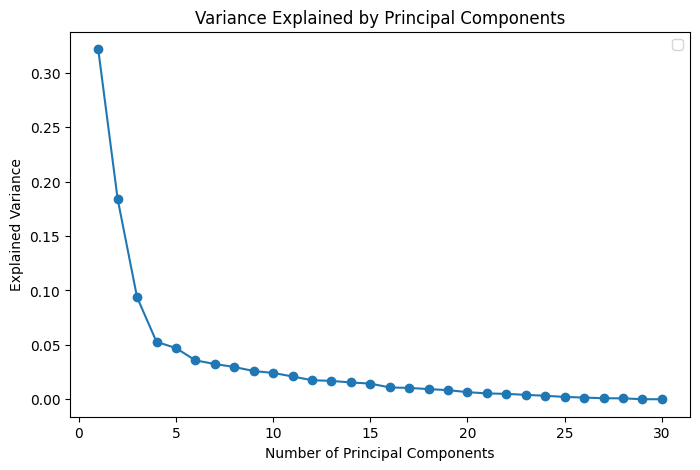

In [5]:
#Keep only numeric features
X = df.select_dtypes(include=[np.number]).dropna(axis=1)
X_std = StandardScaler().fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_std)

# Variance explained
cum_var = np.cumsum(pca.explained_variance_ratio_)

var_pca = pca.explained_variance_ratio_



plt.figure(figsize=(8,5))
plt.plot(range(1,len(var_pca)+1), var_pca, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance")
plt.title("Variance Explained by Principal Components")
plt.legend()
plt.show()

**Answer**:
There are sharp drops for the first 3–4 PCs, and then smaller declines. Likely the first 4–6 PCs capture the majority of useful variation

**Question**

Make a scatterplot matrix of the first four PCs. Do you see a branch pattern?

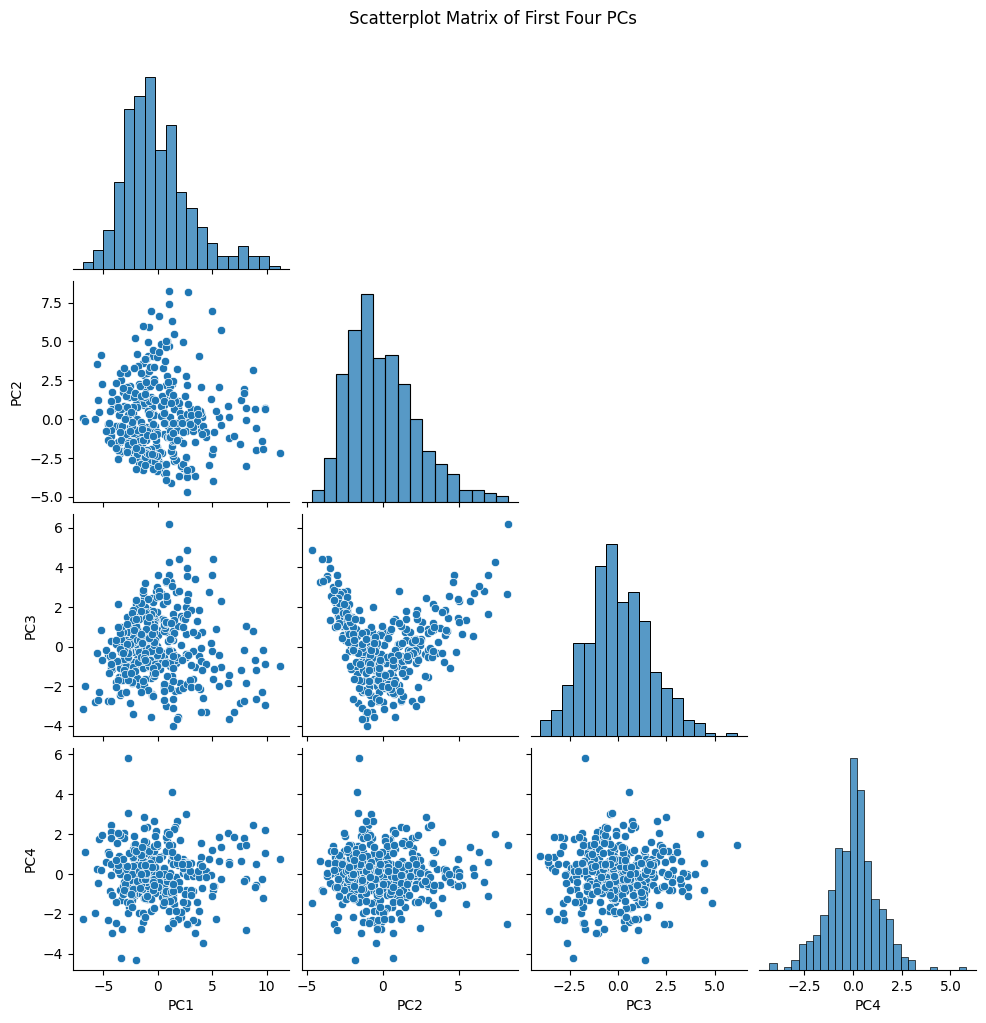

In [6]:
X_pca = pca.transform(X_std)
pc_df = pd.DataFrame(X_pca[:, :4], columns=["PC1","PC2","PC3","PC4"])

sns.pairplot(pc_df, corner=True)
plt.suptitle("Scatterplot Matrix of First Four PCs", y=1.02)
plt.show()

**Answer**

The scatter looks like a fan or branch shape — wide spread along PC1, with PC2 spreading in two opposite directions. This does suggest that PC2 is contrasting two groups of players (likely offensive vs defensive statistics)

**Question**

Interpret your PCs.

PC1 corresponds to which features? PC2? etc

In [7]:
features = pd.DataFrame(pca.components_.T,
                        columns=[f"PC{i+1}" for i in range(len(pca.components_))],
                        index=X.columns)
#sort by PC1 but abs values!!
features.iloc[:, :4].assign(abs_PC1=features["PC1"].abs()) \
       .sort_values("abs_PC1", ascending=False) \
       .head(10)

,PC1,PC2,PC3,PC4,abs_PC1
disposals,0.310680,-0.051038,-0.028246,0.072605,0.310680
possessions,0.309633,-0.034458,-0.070586,0.095769,0.309633
kicks,0.292007,-0.042209,0.093420,-0.117108,0.292007
metres,0.283916,-0.036268,0.100975,-0.150747,0.283916
contested,0.277437,0.005740,-0.119953,0.230222,0.277437
uncontested,0.276881,-0.065186,-0.009887,-0.049926,0.276881
turnovers,0.267832,-0.014156,-0.004955,-0.283863,0.267832
clearances,0.233136,-0.003831,-0.283778,0.197982,0.233136
clangers,0.231841,-0.022492,-0.060788,-0.326507,0.231841
handballs,0.229262,-0.045542,-0.184913,0.307062,0.229262


In [8]:
features.iloc[:, :4].assign(abs_PC2=features["PC2"].abs()) \
       .sort_values("abs_PC2", ascending=False) \
       .head(10)

,PC1,PC2,PC3,PC4,abs_PC2
shots,0.078498,0.380304,0.122957,-0.030349,0.380304
goals,0.039417,0.365968,0.165459,0.037630,0.365968
accuracy,0.036174,0.341787,0.105293,0.066849,0.341787
marks_in50,0.060595,0.339250,0.176611,0.035811,0.339250
behinds,0.087982,0.315782,0.078583,-0.021535,0.315782
intercepts,0.132543,-0.282541,0.243276,0.027557,0.282541
rebounds_in50,0.128051,-0.280697,0.234695,-0.060771,0.280697
tackles_in50,0.066957,0.268956,-0.182621,0.031351,0.268956
assists,0.092037,0.231334,0.001696,0.055731,0.231334
one_pct,0.024197,-0.207978,0.324913,0.080802,0.207978


**Answer**

PC 1 is primarily composed of disposals, possessions, kicks, metres, uncontested, contested, …. primarily the field play statistics!. PCA suggests that the primary variation is through a combination of field skills, or basic football playing skills.

Thus the second PC contrasts the first, because it is primarily a combination of shots, goals, marks_in50, accuracy, and behinds contrasted against rebounds_in50 and intercepts. The positive coefficients are primary offensive skills and the negative coefficients are defensive skills. This PC is reasonable measure of the offensive vs defensive skills of a player.

**Question**

Can you give me a player who have offensive skills? defensive skills?


In [9]:
# Compute PC2 score for each player
df["PC2_score"] = X_std @ features["PC2"].values

# Rank players
top_off = df.sort_values("PC2_score", ascending=False)[["surname", "PC2_score"]].head(10)
top_def = df.sort_values("PC2_score", ascending=True)[["surname", "PC2_score"]].head(10)

print("Top OFFENSIVE players:")
print(top_off)

print("\nTop DEFENSIVE players:")
print(top_def)

Top OFFENSIVE players:
        surname  PC2_score
349  Huntington   8.271892
81     Houghton   8.186962
336      Vescio   7.403219
377     Brennan   6.951841
214   Wakefield   6.933302
305    Davidson   6.639067
380     Stevens   6.310989
198      Walker   5.990799
24     Woodland   5.962665
75     Phillips   5.732677

Top DEFENSIVE players:
         surname  PC2_score
62   Livingstone  -4.704400
28         Allan  -4.117954
210       Ahrens  -4.007604
309      Pregelj  -3.942059
88      McDonald  -3.687441
146   Harrington  -3.661388
44       Lutkins  -3.623847
85       Cordner  -3.496361
38          Pugh  -3.486258
203      Laloifi  -3.431918


**Question**

Plot PCA1 vs PCA2 and use goals as feature to see the defensive or offensive players

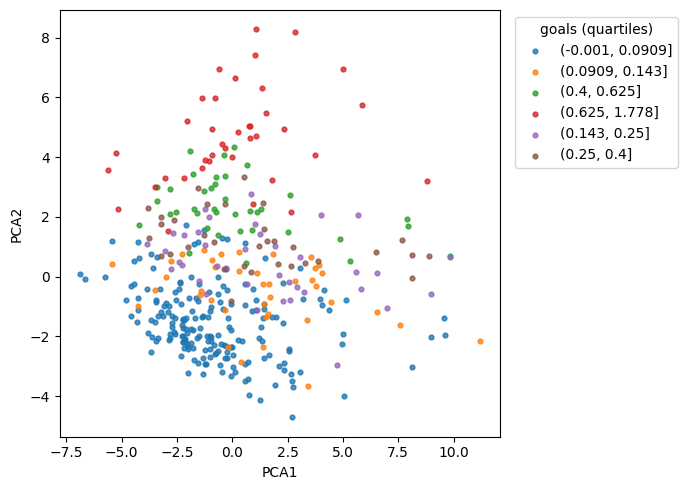

In [10]:
cat_feat='goals'

s = df[cat_feat]
if pd.api.types.is_numeric_dtype(s):
    labels = pd.qcut(s, q=10, duplicates="drop")
    legend_title = f"{cat_feat} (quartiles)"
else:
    labels = s.astype(str)
    legend_title = cat_feat

labels = labels.astype(str).fillna("NA")

plt.figure(figsize=(7,5))
for lab in pd.unique(labels):
    idx = (labels == lab).values
    plt.scatter(X_pca[idx, 0],X_pca[idx, 1], s=12, alpha=0.8, label=str(lab))

plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

#2) t-SNE

**Question**

Conduct your best t-SNE representation of data (position).

To find the best, you should use "Trustworthiness" which measures how well the low-dimensional map preserves the original neighbors.

Trustworthiness = 1.0 → all neighbors in 2D are true neighbors in high-dim space (perfect preservation).

Trustworthiness = 0.9+ → very good preservation.

Trustworthiness < 0.7 → the 2D embedding distorts neighborhoods a lot

from sklearn.manifold import trustworthiness


In [11]:
from sklearn.manifold import TSNE, trustworthiness

perplexities = [5, 10, 20, 30, 40, 50, 100]

#Keep only numeric features
X = df.select_dtypes(include=[np.number]).dropna(axis=1)
X_std = StandardScaler().fit_transform(X)

# Do a loop and save the results
results = []
best = {'tw': -np.inf}

for p in perplexities:
  tsne = TSNE(
      n_components=2,
      perplexity=p,
      learning_rate='auto',
      init='pca',
      max_iter=1000,
      verbose=0,
  )
  Y = tsne.fit_transform(X_std)
  tw = trustworthiness(X_std, Y, n_neighbors=10)
  results.append({'perplexity': p,'trustworthiness': tw})
  if (tw > best['tw']):
      best = {'tw': tw, 'Y': Y,'perplexity': p}

res_df = pd.DataFrame(results).sort_values(['trustworthiness'], ascending=[False])
print("Top t-SNE configs by trustworthiness:")
display(res_df.head(10))

Ybest = best['Y']

Top t-SNE configs by trustworthiness:


,perplexity,trustworthiness
3,30,0.944013
4,40,0.943935
6,100,0.938709
2,20,0.938553
1,10,0.937830
5,50,0.936166
0,5,0.926440


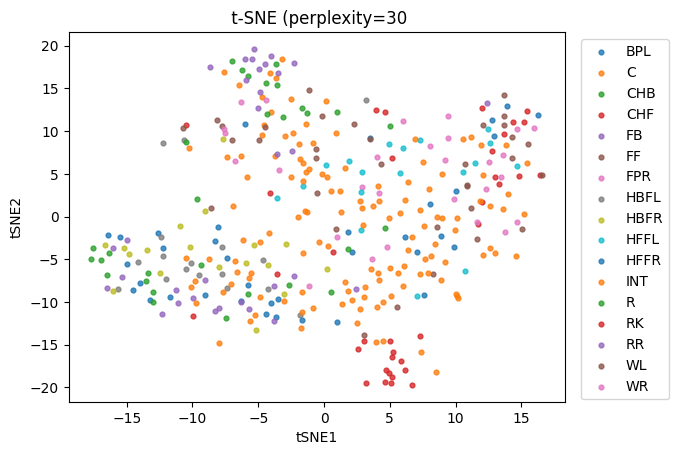

In [12]:
cat_feat='position'

plt.figure()
pos = pd.Categorical(df[cat_feat]).codes
for t in np.unique(pos):
    idx = pos == t
    plt.scatter(Ybest[idx,0], Ybest[idx,1], s=12, alpha=0.8, label=df[cat_feat].iloc[idx].iloc[0])
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title(f" t-SNE (perplexity={best['perplexity']}")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.show()

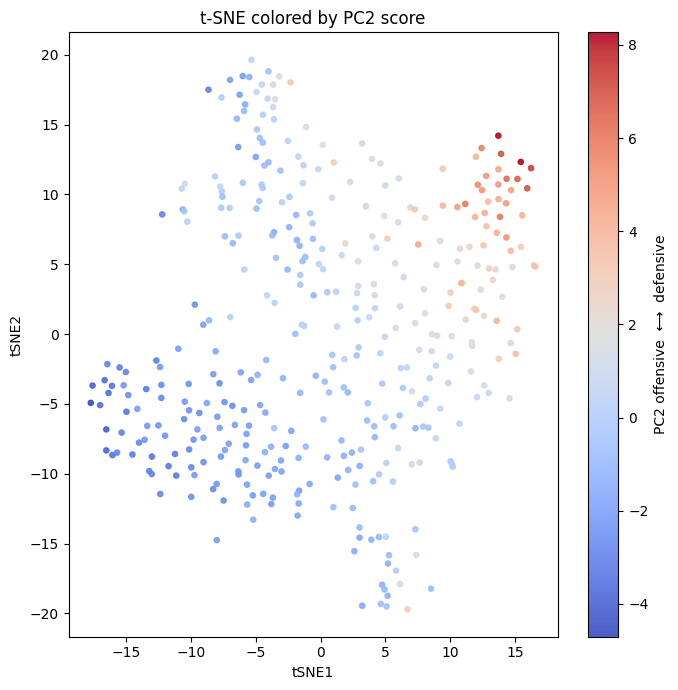

In [13]:
plt.figure(figsize=(7,7))
plt.scatter(Ybest[:,0], Ybest[:,1], s=14, alpha=0.9, c=df["PC2_score"].values, cmap="coolwarm")
plt.colorbar(label="PC2 offensive  ⟷  defensive")
plt.title("t-SNE colored by PC2 score")
plt.xlabel("tSNE1"); plt.ylabel("tSNE2"); plt.tight_layout()
plt.show()

#3) UMAP

**Question**

Conduct your best UMAP representation of data (position).

In [14]:
n_neighbors_list = [5,10, 15, 30, 50]
min_dists = [0.01, 0.05, 0.1, 0.3]

# --- keep only numeric features & standardize ---
X = df.select_dtypes(include=[np.number]).dropna(axis=1)
X_std = StandardScaler().fit_transform(X)

# --- loop and save results ---
results = []
best = {"tw": -np.inf}

for nn in n_neighbors_list:
    for md in min_dists:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=nn,
            min_dist=md,
            random_state=42,
            n_epochs=1000,
        )
        Y = reducer.fit_transform(X_std)
        tw = trustworthiness(X_std, Y, n_neighbors=10)
        results.append({"n_neighbors": nn, "min_dist": md, "trustworthiness": tw})
        if tw > best["tw"]:
            best = {"tw": tw, "Y": Y, "n_neighbors": nn, "min_dist": md}

res_df = pd.DataFrame(results).sort_values("trustworthiness", ascending=False)
print("Top UMAP configs by trustworthiness:")
display(res_df.head(10))

Ybest = best["Y"]  # your best 2D embedding
print("Best:", {k: best[k] for k in ["n_neighbors", "min_dist", "tw"]})

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

Top UMAP configs by trustworthiness:


,n_neighbors,min_dist,trustworthiness
9,15,0.05,0.938191
5,10,0.05,0.937596
10,15,0.10,0.937434
4,10,0.01,0.936354
6,10,0.10,0.935288
8,15,0.01,0.935063
7,10,0.30,0.933588
12,30,0.01,0.933234
13,30,0.05,0.931428
11,15,0.30,0.929726


Best: {'n_neighbors': 15, 'min_dist': 0.05, 'tw': np.float64(0.9381913102175498)}


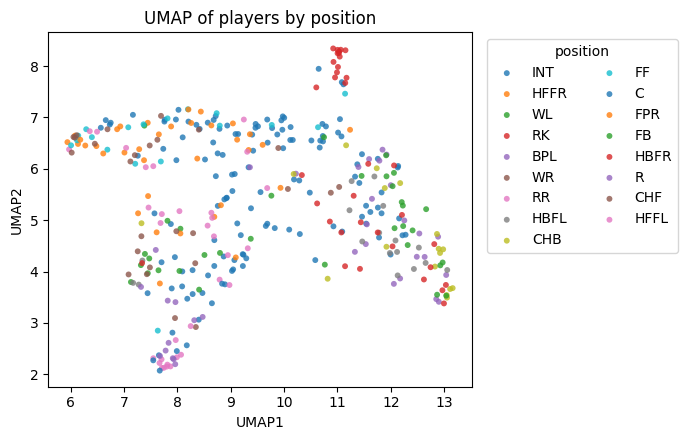

In [15]:
cat_feat='position'

pos = pd.Categorical(df[cat_feat]).codes
labels = df.loc[X.index, "position"].astype(str)  # align with X used for UMAP

fig, ax = plt.subplots(figsize=(7, 4.5))
uniq = pd.unique(labels)
cmap = plt.get_cmap("tab20")
colors = {lab: cmap(i % 20) for i, lab in enumerate(uniq)}

for lab in uniq:
    m = (labels == lab).values
    ax.scatter(Ybest[m, 0], Ybest[m, 1], s=18, alpha=0.8, label=lab, edgecolors="none")

ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
ax.set_title("UMAP of players by position")
ax.legend(title="position", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, ncol=2)
plt.tight_layout(); plt.show()

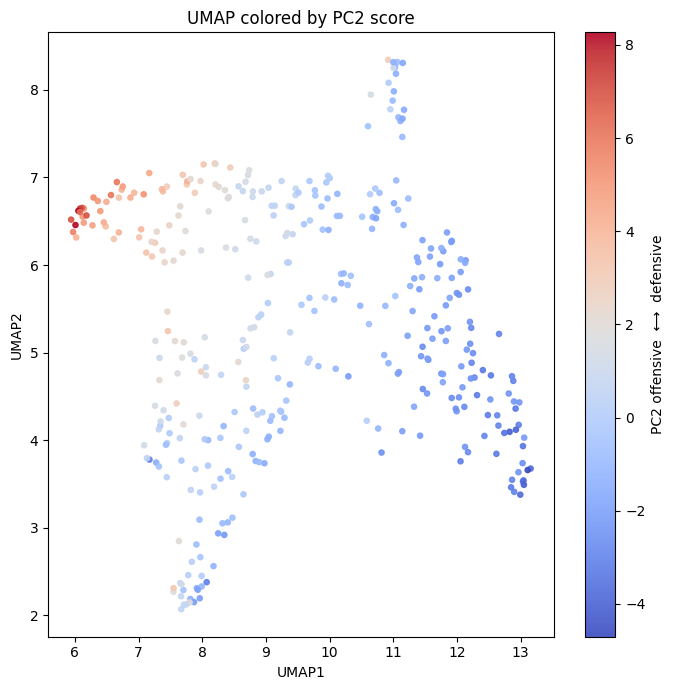

In [16]:
plt.figure(figsize=(7,7))
plt.scatter(Ybest[:,0], Ybest[:,1], s=14, alpha=0.9, c=df["PC2_score"].values, cmap="coolwarm")
plt.colorbar(label="PC2 offensive  ⟷  defensive")
plt.title("UMAP colored by PC2 score")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.tight_layout()
plt.show()

Average PC2 score per UMAP cluster:
UMAP_cluster
1   -1.884598
2    0.015693
0    2.377208
Name: PC2_score, dtype: float64


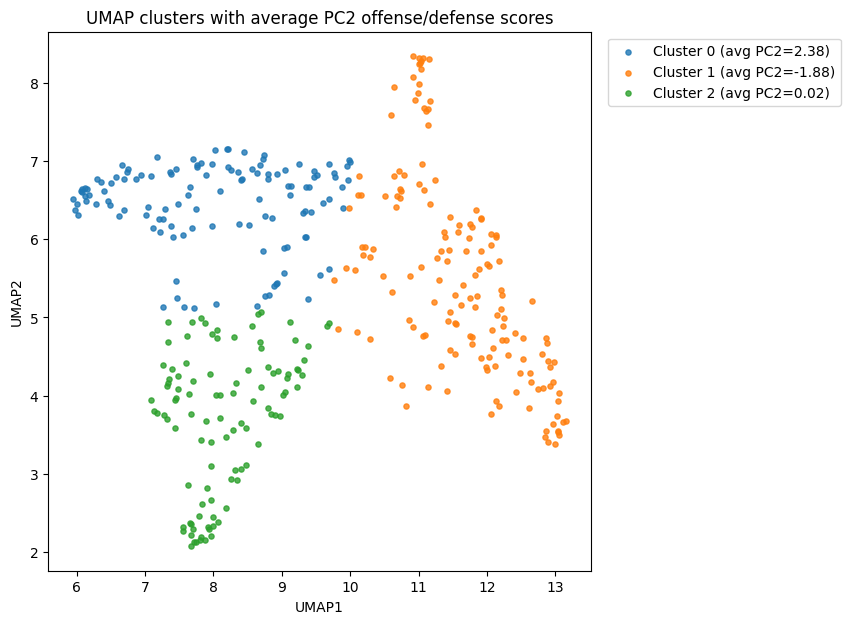

In [20]:
from sklearn.cluster import KMeans

# Run KMeans on UMAP coordinates
k = 3   # choose a reasonable number of clusters
kmeans_umap = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Ybest)
df["UMAP_cluster"] = kmeans_umap.labels_

# Compute average PC2 score per cluster
cluster_means = df.groupby("UMAP_cluster")["PC2_score"].mean().sort_values()
print("Average PC2 score per UMAP cluster:")
print(cluster_means)

# Plot UMAP with cluster colors
plt.figure(figsize=(7,7))
for c in range(k):
    idx = df["UMAP_cluster"] == c
    plt.scatter(Ybest[idx,0], Ybest[idx,1], s=14, alpha=0.8, label=f"Cluster {c} (avg PC2={cluster_means[c]:.2f})")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title("UMAP clusters with average PC2 offense/defense scores")
plt.show()

**Question**

Find players with similar offensive skills using PCA

Hint: use from sklearn.neighbors import NearestNeighbors





In [ ]:
offense_features = [
    "goals", "behinds", "kicks", "handballs", "disposals", "marks_in50", "assists"]

X = df.select_dtypes(include=[np.number]).dropna(axis=1)
X_std = StandardScaler().fit_transform(X)
X_offense = X[offense_features]
X_offense.head()

X_std = StandardScaler().fit_transform(X_offense)

X_feat = PCA(n_components=7, random_state=42).fit_transform(X_std)


from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(X_feat)


In [ ]:
player_name="Huntington"

# locate the player row
idx = np.where(df.surname == player_name)[0]
if len(idx) == 0:
    raise ValueError(f"Player '{player_name}' not found.")
idx = idx[0]
idx


np.int64(349)

In [ ]:
distances, indices = nn.kneighbors(X_feat[idx:idx+1], n_neighbors=6)
distances, indices = distances[0], indices[0]
distances,indices

(array([0.        , 0.01134999, 0.01974485, 0.03451309, 0.0544551 ,
        0.06208894]),
 array([349, 380, 176,  81,  79, 377]))

In [ ]:
sims = 1 - distances
out = pd.DataFrame({
    "player": df.surname[indices],
    "similarity": sims.round(4)
})
out

,player,similarity
349,Huntington,1.0000
380,Stevens,0.9887
176,Toogood,0.9803
81,Houghton,0.9655
79,Shierlaw,0.9455
377,Brennan,0.9379
